- 从2021-03-01开始到今天的数据 https://production.dataviz.cnn.io/index/fearandgreed/graphdata/2021-03-01 。为什么是这个date呢？因为according to https://github.com/whit3rabbit/fear-greed-data 所说，再之前的不准。我没有验证过，之后可以考虑。btw，直接打开保存就是json哒！

- 或者你直接用这个user总结的从2011开始到2023的https://github.com/whit3rabbit/fear-greed-data/blob/main/fear-greed-2011-2023.csv
> I've combined the early data from Hackingthemarket (2011-2016) with openstockalert data (2016-2022) then combined with latest data from CNN (2022-2023).
  -  其实Hackingthemarket给了2011-2020的https://github.com/hackingthemarkets/sentiment-fear-and-greed/blob/master/datasets/fear-greed.csv

In [47]:
import pandas as pd

df = pd.read_json('./data/2021-03-01.json')
# url = 'https://production.dataviz.cnn.io/index/fearandgreed/graphdata/2021-03-01'
# df = pd.read_json(url)

fear_and_greed_historical_data = df["fear_and_greed_historical"]["data"]
fear_and_greed_historical_data[:10]

[{'x': 1614556800000.0, 'y': 58.52, 'rating': 'greed'},
 {'x': 1614643200000.0, 'y': 50.32000000000001, 'rating': 'neutral'},
 {'x': 1614729600000.0, 'y': 43.84, 'rating': 'fear'},
 {'x': 1614816000000.0, 'y': 37.8, 'rating': 'fear'},
 {'x': 1614902400000.0, 'y': 41.52, 'rating': 'fear'},
 {'x': 1615161600000.0, 'y': 39.08, 'rating': 'fear'},
 {'x': 1615248000000.0, 'y': 43.36, 'rating': 'fear'},
 {'x': 1615334400000.0, 'y': 45.56, 'rating': 'neutral'},
 {'x': 1615420800000.0, 'y': 50.480000000000004, 'rating': 'neutral'},
 {'x': 1615507200000.0, 'y': 53.720000000000006, 'rating': 'neutral'}]

In [40]:
len(df["fear_and_greed_historical"]["data"])

1050

In [41]:
type(fear_and_greed_historical_data)

list

In [42]:
import datetime

# timestamp_ms = fear_and_greed_historical_data[0]["x"]
timestamp_ms = 1643760000000.0
timestamp_s = timestamp_ms / 1000  # convert
dt = datetime.datetime.utcfromtimestamp(timestamp_s)
print(dt, type(dt))

dt = str(dt)
print(dt, type(dt))

2022-02-02 00:00:00 <class 'datetime.datetime'>
2022-02-02 00:00:00 <class 'str'>


In [46]:
import copy
fear_and_greed_historical_data_utc = copy.deepcopy(fear_and_greed_historical_data)
# fear_and_greed_historical_data_utc = fear_and_greed_historical_data

for i in range(len(fear_and_greed_historical_data_utc)):
  timestamp_ms = fear_and_greed_historical_data_utc[i]["x"]
  timestamp_s = timestamp_ms / 1000  # convert
  dt = datetime.datetime.utcfromtimestamp(timestamp_s)
  dt = str(dt)
  fear_and_greed_historical_data_utc[i]["x"] = dt

fear_and_greed_historical_data_utc[:10]

[{'x': '2021-03-01 00:00:00', 'y': 58.52, 'rating': 'greed'},
 {'x': '2021-03-02 00:00:00', 'y': 50.32000000000001, 'rating': 'neutral'},
 {'x': '2021-03-03 00:00:00', 'y': 43.84, 'rating': 'fear'},
 {'x': '2021-03-04 00:00:00', 'y': 37.8, 'rating': 'fear'},
 {'x': '2021-03-05 00:00:00', 'y': 41.52, 'rating': 'fear'},
 {'x': '2021-03-08 00:00:00', 'y': 39.08, 'rating': 'fear'},
 {'x': '2021-03-09 00:00:00', 'y': 43.36, 'rating': 'fear'},
 {'x': '2021-03-10 00:00:00', 'y': 45.56, 'rating': 'neutral'},
 {'x': '2021-03-11 00:00:00', 'y': 50.480000000000004, 'rating': 'neutral'},
 {'x': '2021-03-12 00:00:00', 'y': 53.720000000000006, 'rating': 'neutral'}]

**EMOTION	RANGE**
*   Extreme Fear	0-24
*   Fear	25-49
*   Neutral	50
*   Greed	51-74
*   Extreme Greed	75-100

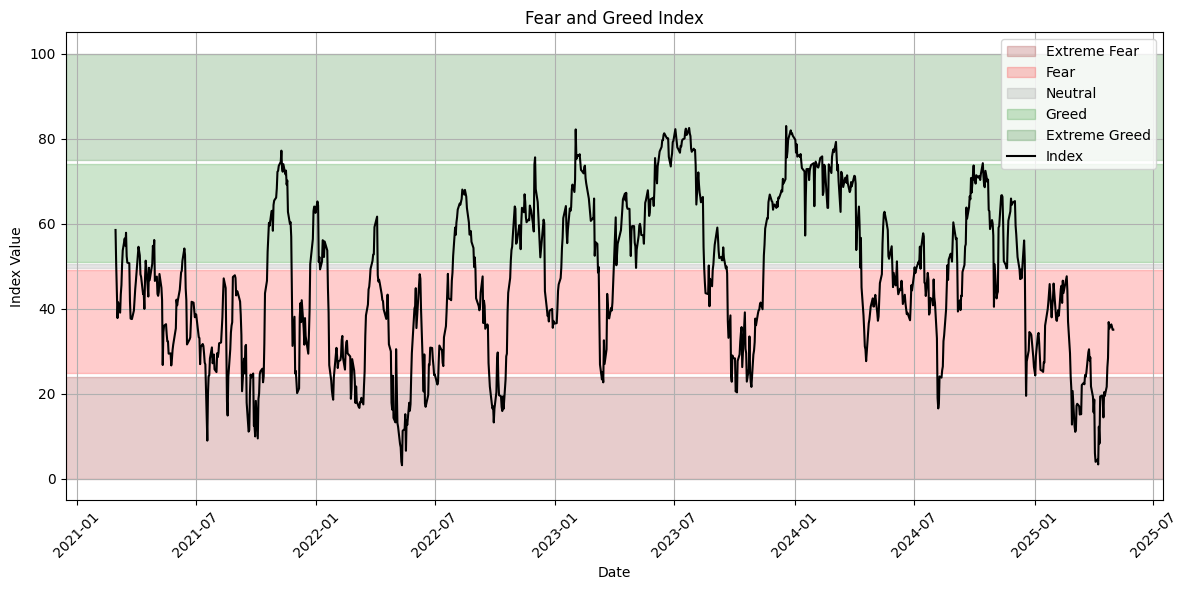

In [49]:
import matplotlib.pyplot as plt
from datetime import datetime

# x:date , y:sentiment score
dates = [datetime.strptime(item['x'], '%Y-%m-%d %H:%M:%S') for item in fear_and_greed_historical_data_utc]
values = [item['y'] for item in fear_and_greed_historical_data_utc]

# emotion range
def get_emotion_color(y):
    if y <= 24:
        return 'darkred', 'Extreme Fear'
    elif 25 <= y <= 49:
        return 'red', 'Fear'
    elif y == 50:
        return 'gray', 'Neutral'
    elif 51 <= y <= 74:
        return 'green', 'Greed'
    else:  # y >= 75
        return 'darkgreen', 'Extreme Greed'

colors = []
labels = []
for y in values:
    color, label = get_emotion_color(y)
    colors.append(color)
    labels.append(label)

########
fig, ax = plt.subplots(figsize=(12, 6))

# ax.axhspan to add a horizontal span (rectangle) across the Axes
emotion_zones = [
    (0, 24, 'Extreme Fear', 'darkred', 0.2),
    (25, 49, 'Fear', 'red', 0.2),
    (49.5, 50.5, 'Neutral', 'gray', 0.2),
    (51, 74, 'Greed', 'green', 0.2),
    (75, 100, 'Extreme Greed', 'darkgreen', 0.2),
]

for low, high, label, color, alpha in emotion_zones:
    ax.axhspan(low, high, color=color, alpha=alpha, label=label)

ax.plot(dates, values, color='black', label='Index')
ax.set_title('Fear and Greed Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.grid(True)
plt.xticks(rotation=45)

# create a legend ~
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

他的数据1/3/2011 - 12/29/2023，所以需要我们把12/29/2023之后的给接上。但是我发现12/29/2023左右的数据和CNN自己的不一样，很奇怪。所以暂时先搁置这个操作。